# Wingspan Engine Efficiency: Stochastic Modeling of Resource Production

> *Every bird you play either scores points or generates resources. The art of Wingspan is knowing when each matters.*

Wingspan is a card-laying engine builder. Each round you take fewer turns,
which creates a fundamental tension: spend a turn **playing a bird** (costs food,
adds a power to your engine) or **activate your habitat** (gains food + triggers
every bird you've already played).

This notebook models the **forest habitat** engine (the food-production engine of the game)
and answers the central question:

**When does adding a bird to your engine pay off more than playing a high-point bird?**

The answer turns on three things:
- How much output the bird generates per activation
- How much it costs to play
- How many activations remain in the game when you play it

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import birds  as brd
import engine as eng

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "text.color":       "#dde8f0",
    "axes.edgecolor":   "#2a4a6a",
    "axes.labelcolor":  "#dde8f0",
    "xtick.color":      "#dde8f0",
    "ytick.color":      "#dde8f0",
    "grid.color":       "#1e3040",
    "grid.alpha":       0.4,
})
# print("birds.py  :", brd.__file__)
# print("engine.py :", eng.__file__)
print("Imports complete.")
print(f"Forest birds modeled: {len(brd.FOREST_BIRDS)}")

Imports complete.
Forest birds modeled: 19


## The Bird Catalog

Before analyzing engines, let's understand the raw material: the birds available
for the forest habitat, their costs, points, and expected output per activation.

In [2]:
# Print the full bird catalog sorted by efficiency
print("FOREST BIRD CATALOG sorted by efficiency (output per food cost)")
print(f"{'Name':<28} {'Type':<20} {'Cost':>5} {'Pts':>4} "
      f"{'Output/act':>11} {'Efficiency':>11}")

for b in sorted(brd.FOREST_BIRDS, key=lambda x: x.efficiency, reverse=True):
    eff_str = f"{b.efficiency:.3f}" if b.efficiency != float('inf') else "inf"
    print(f"  {b.name:<26} {b.power_type.name:<20} {b.food_cost:>5} "
          f"{b.points:>4} {b.expected_food_output:>11.2f} {eff_str:>11}")

FOREST BIRD CATALOG sorted by efficiency (output per food cost)
Name                         Type                  Cost  Pts  Output/act  Efficiency
  Black-capped Chickadee     CACHE_FOOD               1    3        1.00       1.000
  Red-breasted Nuthatch      CACHE_FOOD               2    4        2.00       1.000
  Ruffed Grouse              ROLL_FOOD                2    5        1.67       0.833
  Blue Grouse                ROLL_FOOD                3    6        2.50       0.833
  Brown-headed Cowbird       COPY_NEIGHBOR            1    2        0.80       0.800
  Northern Goshawk           GAIN_FOOD                4    7        3.00       0.750
  Clark's Nutcracker         GAIN_FOOD                3    6        2.00       0.667
  Great Horned Owl           GAIN_FOOD                3    7        2.00       0.667
  Common Raven               GAIN_FOOD                2    4        1.00       0.500
  Steller's Jay              GAIN_FOOD                2    5        1.00       0.500
 

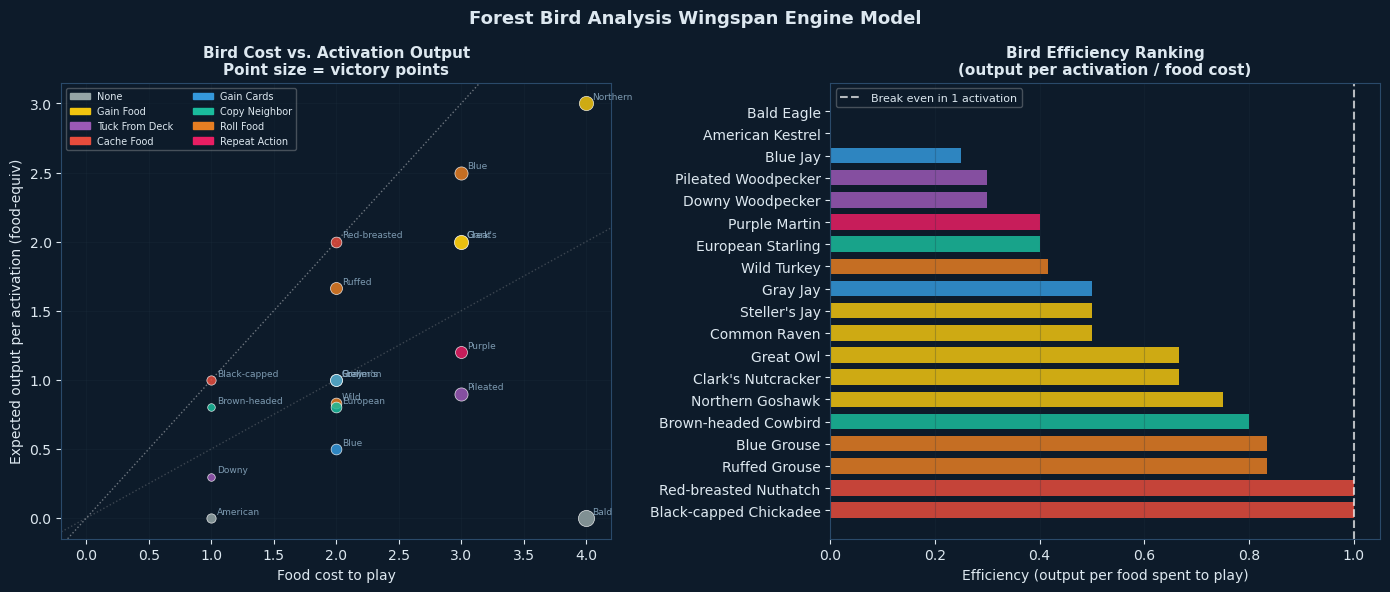

In [10]:
# Visualize the bird population by power type and cost tier
power_types = list(brd.PowerType)
POWER_COLORS = {
    brd.PowerType.NONE:           "#95a5a6",
    brd.PowerType.GAIN_FOOD:      "#f1c40f",
    brd.PowerType.ROLL_FOOD:      "#e67e22",
    brd.PowerType.CACHE_FOOD:     "#e74c3c",
    brd.PowerType.GAIN_CARDS:     "#3498db",
    brd.PowerType.TUCK_FROM_DECK: "#9b59b6",
    brd.PowerType.COPY_NEIGHBOR:  "#1abc9c",
    brd.PowerType.REPEAT_ACTION:  "#e91e63",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: cost vs output, colored by power type
ax = axes[0]
for b in brd.FOREST_BIRDS:
    color = POWER_COLORS[b.power_type]
    ax.scatter(b.food_cost, b.expected_food_output,
               color=color, s=b.points * 15,
               alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)
    ax.annotate(b.name.split()[0], (b.food_cost, b.expected_food_output),
                textcoords="offset points", xytext=(4, 3),
                fontsize=6.5, color="#90b0c8", alpha=0.85)

ax.axline((0,0), slope=1, color="white", linewidth=1,
          linestyle=":", alpha=0.4, label="1:1 (break even in 1 activation)")
ax.axline((0,0), slope=0.5, color="#aaa", linewidth=1,
          linestyle=":", alpha=0.3, label="0.5:1")
ax.set_xlabel("Food cost to play")
ax.set_ylabel("Expected output per activation (food-equiv)")
ax.set_title("Bird Cost vs. Activation Output\nPoint size = victory points",
             fontsize=11, fontweight="bold")
legend_el = [mpatches.Patch(color=POWER_COLORS[pt], label=pt.name.replace("_"," ").title())
             for pt in brd.PowerType]
ax.legend(handles=legend_el, fontsize=7, loc="upper left",
          framealpha=0.3, ncol=2)
ax.grid(alpha=0.25)

# Right: efficiency bar chart
ax = axes[1]
sorted_birds = sorted(brd.FOREST_BIRDS, key=lambda b: b.efficiency, reverse=True)
names = [b.name.split()[0] + " " + b.name.split()[-1] if len(b.name.split())>1
         else b.name for b in sorted_birds]
effs  = [min(b.efficiency, 3.0) for b in sorted_birds]  # cap inf at 3.0
colors = [POWER_COLORS[b.power_type] for b in sorted_birds]
ax.barh(names, effs, color=colors, alpha=0.85, height=0.7)
ax.axvline(1.0, color="white", linewidth=1.5, linestyle="--", alpha=0.7,
           label="Break even in 1 activation")
ax.set_xlabel("Efficiency (output per food spent to play)")
ax.set_title("Bird Efficiency Ranking\n(output per activation / food cost)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(axis="x", alpha=0.25)

plt.suptitle("Forest Bird Analysis Wingspan Engine Model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Breakeven Analysis

Every bird that generates engine output has a **breakeven turn**: the point
at which its cumulative output equals the food you spent to play it.

Before breakeven: you're in debt (net negative).
After breakeven: every activation is pure profit.

A bird played on turn 20 of a 26-turn game only gets ~3 activations
(assuming you activate your forest roughly every other turn). A bird with
efficiency 0.5 needs 4 activations to break even, it never pays off if
played that late.

This is the core insight: **late-game engine birds are a trap.**

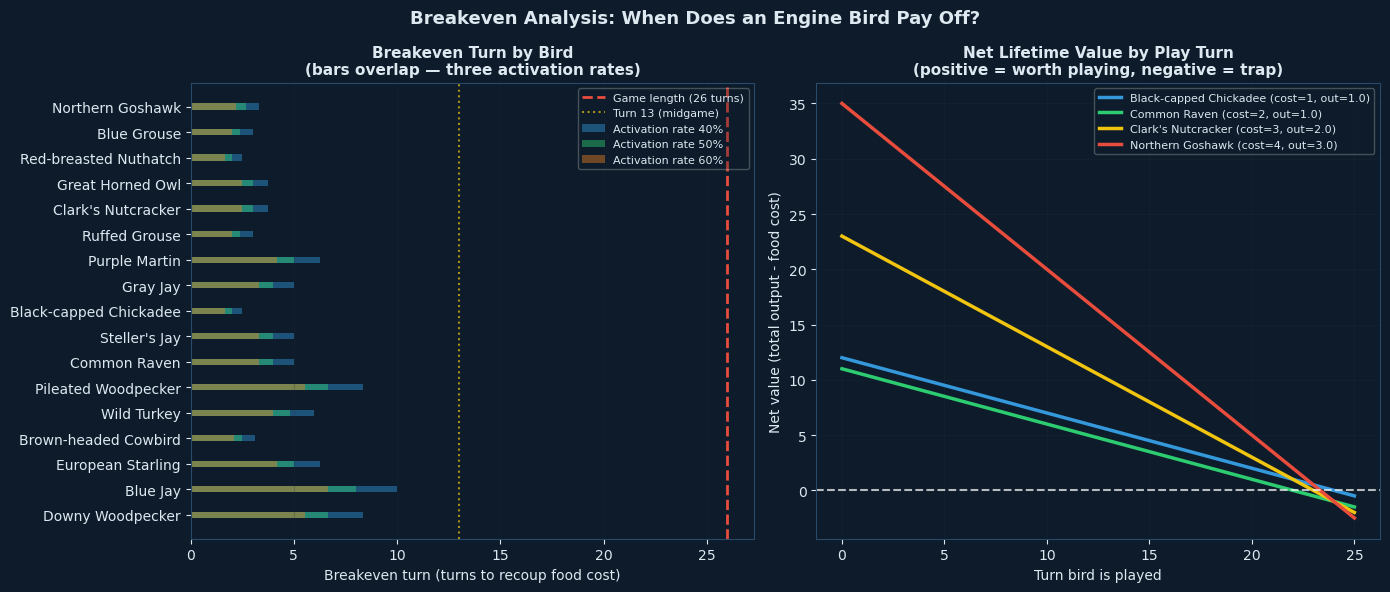

Critical insight: a bird played too late has negative net value.
It costs more to play than it will ever produce.


In [ ]:
# Breakeven turn for each bird at different activation rates
activation_rates = [0.4, 0.5, 0.6]   # fraction of turns spent gaining food
TOTAL_TURNS = eng.TOTAL_TURNS

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: breakeven turn by bird
ax = axes[0]
engine_birds = [b for b in brd.FOREST_BIRDS
                if b.power_type != brd.PowerType.NONE]
engine_birds_sorted = sorted(engine_birds, key=lambda b: b.expected_food_output)

y_pos = range(len(engine_birds_sorted))
rate_colors = ["#3498db", "#2ecc71", "#e67e22"]

for rate, rcolor in zip(activation_rates, rate_colors):
    bts = [eng.breakeven_turn(b, rate) for b in engine_birds_sorted]
    ax.barh([b.name for b in engine_birds_sorted], bts,
            alpha=0.45, color=rcolor, height=0.25,
            label=f"Activation rate {rate:.0%}",
            left=[i*0 for i in range(len(bts))])

ax.axvline(TOTAL_TURNS, color="#e74c3c", linewidth=2, linestyle="--",
           label=f"Game length ({TOTAL_TURNS} turns)")
ax.axvline(TOTAL_TURNS * 0.5, color="#f1c40f", linewidth=1.5, linestyle=":",
           alpha=0.7, label="Turn 13 (midgame)")
ax.set_xlabel("Breakeven turn (turns to recoup food cost)")
ax.set_title("Breakeven Turn by Bird\n(bars overlap three activation rates)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(axis="x", alpha=0.25)

# Right: net value at end of game if played on turn T
ax = axes[1]
turns = range(0, TOTAL_TURNS)
selected = [
    brd.BIRD_BY_NAME["Black-capped Chickadee"],
    brd.BIRD_BY_NAME["Common Raven"],
    brd.BIRD_BY_NAME["Clark's Nutcracker"],
    brd.BIRD_BY_NAME["Northern Goshawk"],
]
line_colors = ["#3498db","#2ecc71","#f1c40f","#e74c3c"]

for bird, color in zip(selected, line_colors):
    net_values = [
        eng.marginal_value(bird, [], TOTAL_TURNS - t, n_activations_per_turn=0.5)
        for t in turns
    ]
    ax.plot(turns, net_values, color=color, linewidth=2.5,
            label=f"{bird.name} (cost={bird.food_cost}, out={bird.expected_food_output:.1f})")

ax.axhline(0, color="white", linewidth=1.5, linestyle="--", alpha=0.7)
ax.fill_between(turns, 0, 0, alpha=0)
ax.set_xlabel("Turn bird is played")
ax.set_ylabel("Net value (total output - food cost)")
ax.set_title("Net Lifetime Value by Play Turn\n(positive = worth playing, negative = trap)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.25)

plt.suptitle("Breakeven Analysis: When Does an Engine Bird Pay Off?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Critical insight: a bird played too late has negative net value.")
print("It costs more to play than it will ever produce.")

## Engine Output Over Time

Now let's simulate full games and watch how engine output evolves as birds
are added to the forest. We track four build strategies:

- **Pure Points**: play high-point, no-power birds (baseline: no engine)
- **Food Engine**: GAIN_FOOD birds in order of power value
- **Dice Engine**: ROLL_FOOD birds (stochastic, high ceiling)
- **Mixed Engine**: blend of caching, food, and card draw

In [5]:
configs = {
    "Pure Points (no engine)": eng.make_config_pure_points(),
    "Food Engine (GAIN_FOOD)": eng.make_config_food_engine(),
    "Dice Engine (ROLL_FOOD)": eng.make_config_dice_engine(),
    "Mixed Engine":            eng.make_config_mixed(),
}

print("Running simulations (500 games each)...")
results = {}
for name, config in configs.items():
    results[name] = eng.simulate_engine(config)
    print(f"  {name}: done")
print("Complete.")

Running simulations (500 games each)...
  Pure Points (no engine): done
  Food Engine (GAIN_FOOD): done
  Dice Engine (ROLL_FOOD): done
  Mixed Engine: done
Complete.


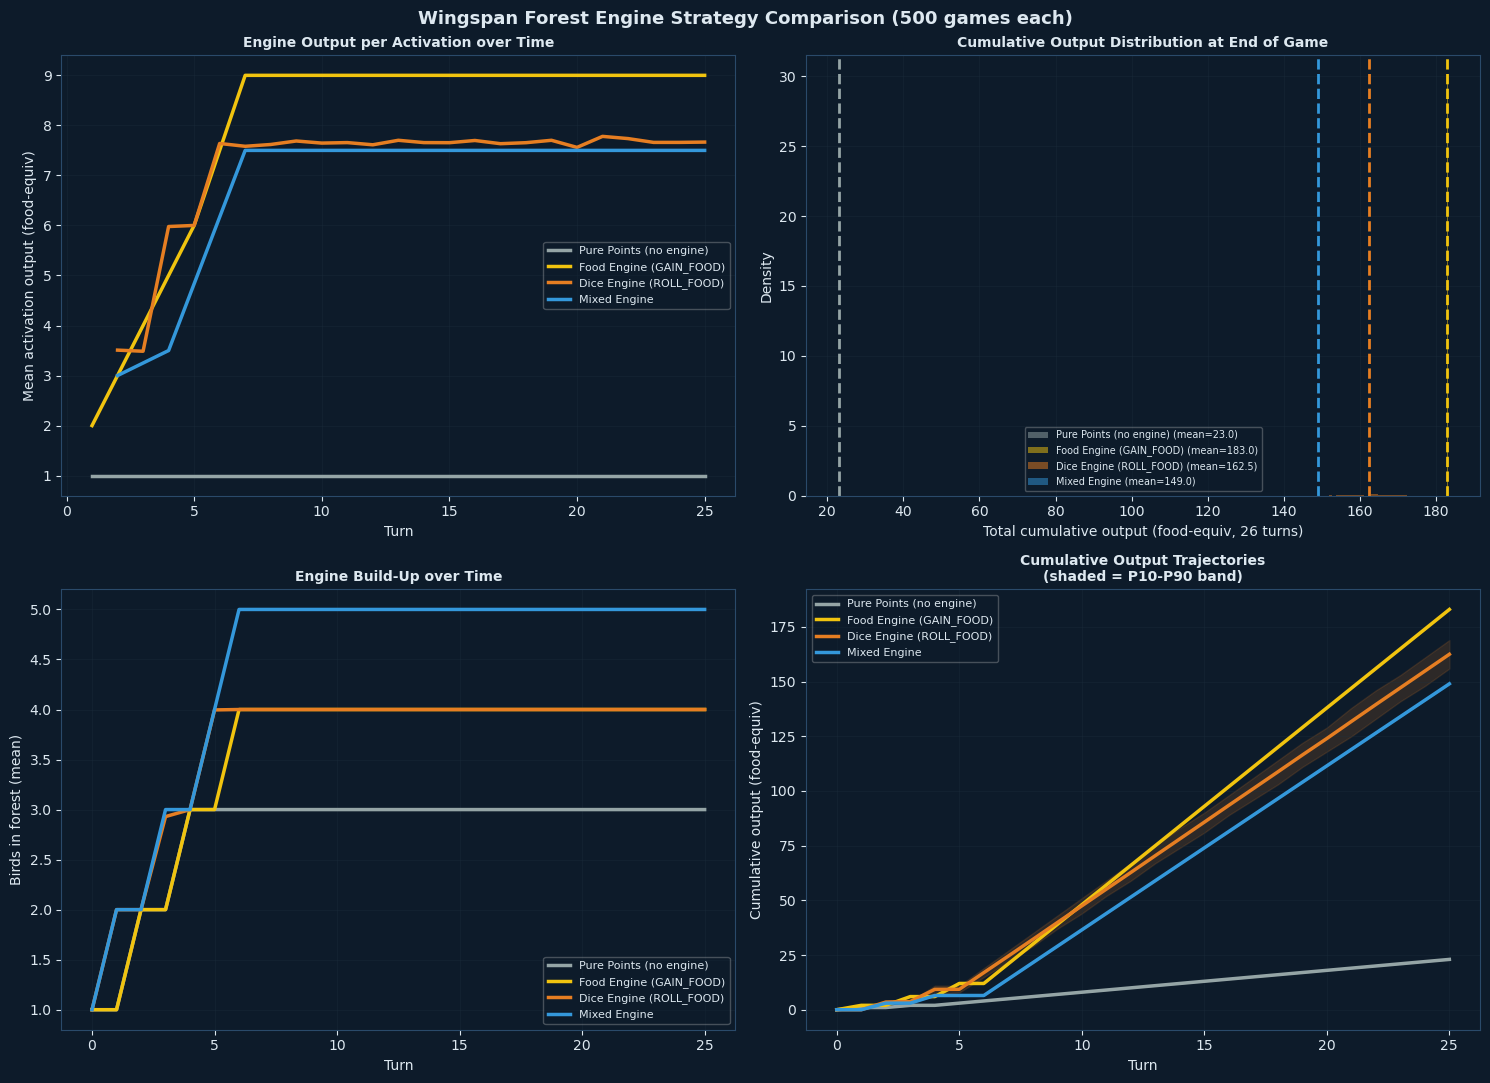

In [6]:
STRATEGY_COLORS = {
    "Pure Points (no engine)": "#95a5a6",
    "Food Engine (GAIN_FOOD)": "#f1c40f",
    "Dice Engine (ROLL_FOOD)": "#e67e22",
    "Mixed Engine":            "#3498db",
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Top left: mean activation output per turn
ax = axes[0][0]
for name, df in results.items():
    color   = STRATEGY_COLORS[name]
    act_df  = df[df["action"] == "gain_food"].copy()
    mean_by_turn = act_df.groupby("turn")["activation_output"].mean()
    ax.plot(mean_by_turn.index, mean_by_turn.values,
            color=color, linewidth=2.5, label=name)
ax.set_xlabel("Turn")
ax.set_ylabel("Mean activation output (food-equiv)")
ax.set_title("Engine Output per Activation over Time",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.3)

# Top right: cumulative output distribution at end of game
ax = axes[0][1]
for name, df in results.items():
    color    = STRATEGY_COLORS[name]
    end_vals = df.groupby("game")["cumulative_output"].last()
    ax.hist(end_vals, bins=30, color=color, alpha=0.5,
            label=f"{name} (mean={end_vals.mean():.1f})", density=True)
    ax.axvline(end_vals.mean(), color=color, linewidth=2, linestyle="--")
ax.set_xlabel("Total cumulative output (food-equiv, 26 turns)")
ax.set_ylabel("Density")
ax.set_title("Cumulative Output Distribution at End of Game",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=7, framealpha=0.3)
ax.grid(alpha=0.3)

# Bottom left: engine size over time
ax = axes[1][0]
for name, df in results.items():
    color = STRATEGY_COLORS[name]
    mean_size = df.groupby("turn")["engine_size"].mean()
    ax.plot(mean_size.index, mean_size.values,
            color=color, linewidth=2.5, label=name)
ax.set_xlabel("Turn")
ax.set_ylabel("Birds in forest (mean)")
ax.set_title("Engine Build-Up over Time",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.3)

# Bottom right: cumulative output trajectories with P10-P90
ax = axes[1][1]
for name, df in results.items():
    color = STRATEGY_COLORS[name]
    mean_traj = df.groupby("turn")["cumulative_output"].mean()
    p10_traj  = df.groupby("turn")["cumulative_output"].quantile(0.10)
    p90_traj  = df.groupby("turn")["cumulative_output"].quantile(0.90)
    ax.fill_between(mean_traj.index, p10_traj, p90_traj,
                    color=color, alpha=0.15)
    ax.plot(mean_traj.index, mean_traj, color=color, linewidth=2.5,
            label=name)
ax.set_xlabel("Turn")
ax.set_ylabel("Cumulative output (food-equiv)")
ax.set_title("Cumulative Output Trajectories\n(shaded = P10-P90 band)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.3)

plt.suptitle("Wingspan Forest Engine Strategy Comparison (500 games each)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## The Tipping Point: When Does the Engine Pull Ahead?

The pure-points strategy starts strong (birds played early don't need
to break even on resource generation). The engine strategies start slower
but compound over time. Where exactly does the crossover happen?

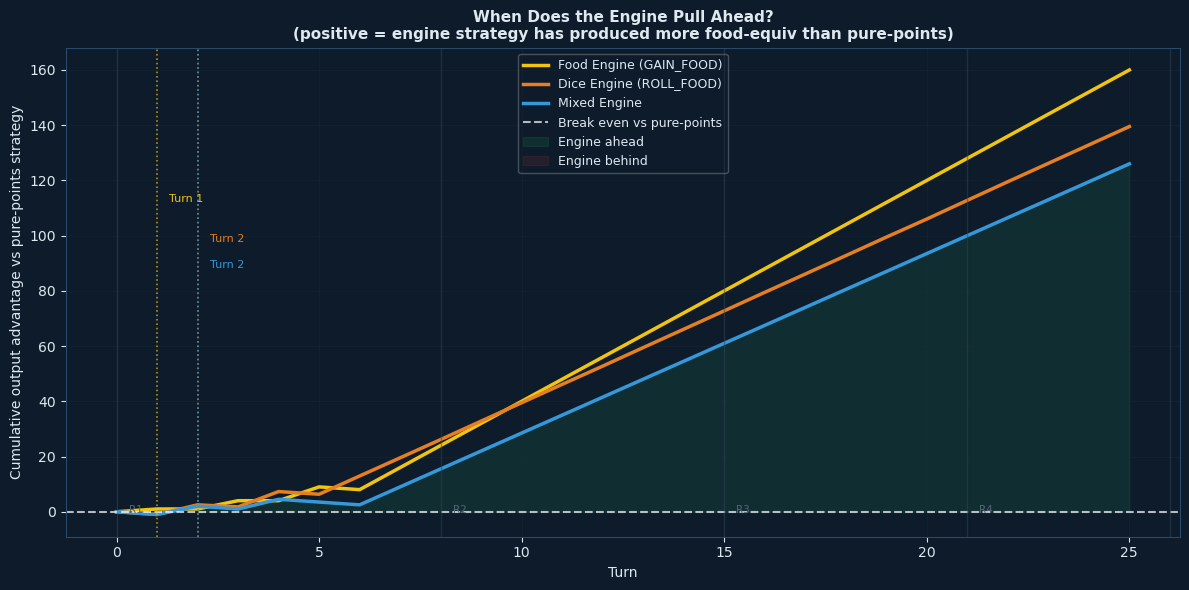

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, df in results.items():
    if name == "Pure Points (no engine)":
        continue
    color    = STRATEGY_COLORS[name]
    baseline = results["Pure Points (no engine)"].groupby("turn")["cumulative_output"].mean()
    engine   = df.groupby("turn")["cumulative_output"].mean()
    advantage = engine - baseline
    ax.plot(advantage.index, advantage.values, color=color,
            linewidth=2.5, label=name)

ax.axhline(0, color="white", linewidth=1.5, linestyle="--", alpha=0.7,
           label="Break even vs pure-points")
ax.fill_between(advantage.index,
                advantage.values, 0,
                where=advantage.values > 0,
                alpha=0.1, color="#2ecc71", label="Engine ahead")
ax.fill_between(advantage.index,
                advantage.values, 0,
                where=advantage.values < 0,
                alpha=0.1, color="#e74c3c", label="Engine behind")

# Mark crossover points
for name, df in results.items():
    if name == "Pure Points (no engine)": continue
    color    = STRATEGY_COLORS[name]
    baseline = results["Pure Points (no engine)"].groupby("turn")["cumulative_output"].mean()
    engine   = df.groupby("turn")["cumulative_output"].mean()
    advantage = engine - baseline
    crossover = advantage[advantage > 0]
    if not crossover.empty:
        first_cross = crossover.index[0]
        ax.axvline(first_cross, color=color, linewidth=1.2,
                   linestyle=":", alpha=0.7)
        ax.text(first_cross + 0.3, advantage.max() * 0.7,
                f"Turn {first_cross}",
                color=color, fontsize=8)

# Round boundaries
for t in [0, 8, 15, 21, 26]:
    ax.axvline(t, color="#334455", linewidth=1, alpha=0.5)
    if t < 26:
        ax.text(t + 0.3, ax.get_ylim()[0] if ax.get_ylim()[0] > -1 else -0.5,
                f"R{[0,8,15,21,26].index(t)+1}", fontsize=7.5,
                color="#556677")

ax.set_xlabel("Turn")
ax.set_ylabel("Cumulative output advantage vs pure-points strategy")
ax.set_title("When Does the Engine Pull Ahead?\n"
             "(positive = engine strategy has produced more food-equiv than pure-points)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Variance: The Cost of Dice

The dice engine (ROLL_FOOD) and the food engine (GAIN_FOOD) may have
similar means, but very different variance. High variance is a liability
in a game where you need specific amounts of food to play specific birds.

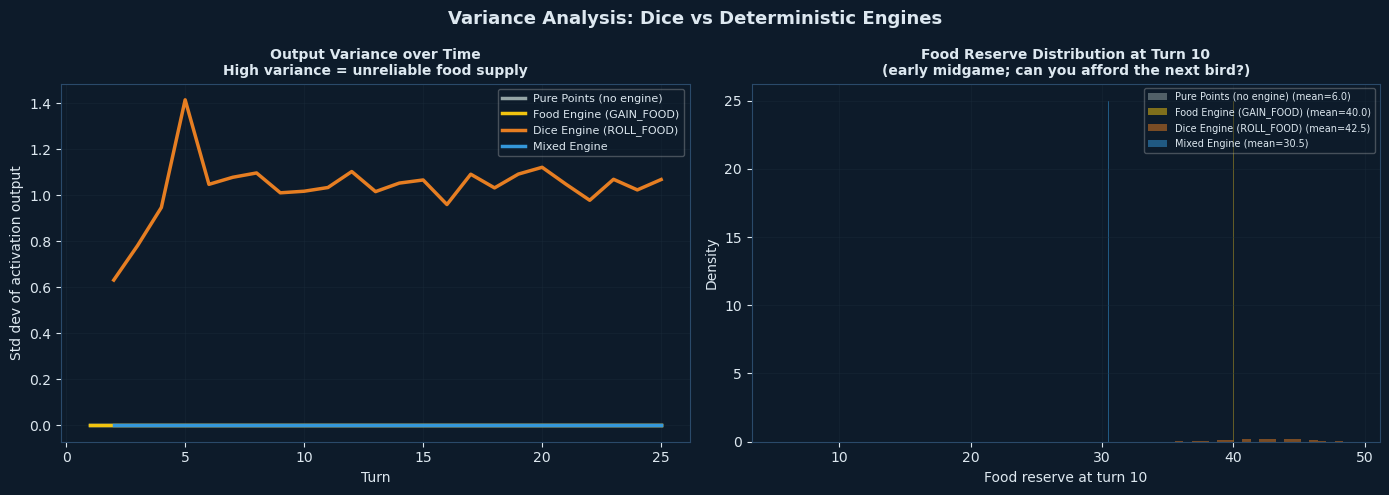

COEFFICIENT OF VARIATION (std/mean) of end-game cumulative output
Higher CV = less predictable engine performance

  Pure Points (no engine)            : CV = 0.000  (mean=23.0, std=0.0)
  Food Engine (GAIN_FOOD)            : CV = 0.000  (mean=183.0, std=0.0)
  Dice Engine (ROLL_FOOD)            : CV = 0.031  (mean=162.5, std=5.0)
  Mixed Engine                       : CV = 0.000  (mean=149.0, std=0.0)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: variance of activation output by strategy
ax = axes[0]
for name, df in results.items():
    color  = STRATEGY_COLORS[name]
    act_df = df[df["action"] == "gain_food"]
    std_by_turn = act_df.groupby("turn")["activation_output"].std()
    ax.plot(std_by_turn.index, std_by_turn.values,
            color=color, linewidth=2.5, label=name)
ax.set_xlabel("Turn")
ax.set_ylabel("Std dev of activation output")
ax.set_title("Output Variance over Time\nHigh variance = unreliable food supply",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.3)

# Right: food reserve distribution at turn 10 (early game)
ax = axes[1]
turn_check = 10
for name, df in results.items():
    color   = STRATEGY_COLORS[name]
    reserve = df[df["turn"] == turn_check]["food_reserve"]
    ax.hist(reserve, bins=25, color=color, alpha=0.5, density=True,
            label=f"{name} (mean={reserve.mean():.1f})")
ax.set_xlabel(f"Food reserve at turn {turn_check}")
ax.set_ylabel("Density")
ax.set_title(f"Food Reserve Distribution at Turn {turn_check}\n"
             f"(early midgame; can you afford the next bird?)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=7, framealpha=0.3)
ax.grid(alpha=0.3)

plt.suptitle("Variance Analysis: Dice vs Deterministic Engines",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Coefficient of variation summary
print("COEFFICIENT OF VARIATION (std/mean) of end-game cumulative output")
print("Higher CV = less predictable engine performance")
print()
for name, df in results.items():
    end_vals = df.groupby("game")["cumulative_output"].last()
    cv = end_vals.std() / end_vals.mean()
    print(f"  {name:<35}: CV = {cv:.3f}  "
          f"(mean={end_vals.mean():.1f}, std={end_vals.std():.1f})")

## Single Bird Marginal Value Calculator

Given how many turns remain, should you play a specific bird or keep
activating your existing engine? This cell calculates the net expected
value of playing each bird at each point in the game.

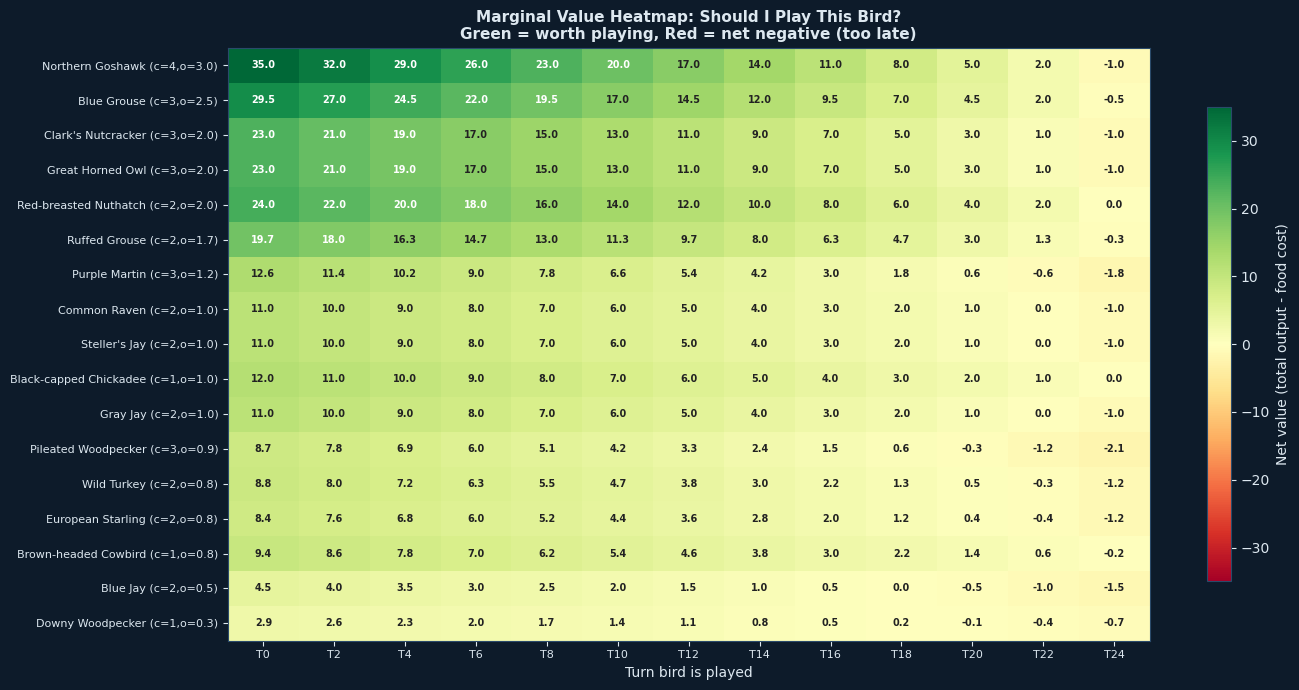

Rule of thumb: green cells are profitable plays.
A red cell means the bird costs more than it will ever produce.
The transition from green to red is the 'play deadline' for each bird.


In [9]:
# Marginal value heatmap: bird vs turn played
turns_to_analyze = list(range(0, 26, 2))  # every other turn
engine_birds     = [b for b in brd.FOREST_BIRDS
                    if b.power_type != brd.PowerType.NONE]
engine_birds_sorted = sorted(engine_birds,
                              key=lambda b: b.expected_food_output, reverse=True)

grid = np.array([
    [eng.marginal_value(bird, [], eng.TOTAL_TURNS - t, 0.5)
     for t in turns_to_analyze]
    for bird in engine_birds_sorted
])

fig, ax = plt.subplots(figsize=(14, 7))
vmax = max(abs(grid.min()), abs(grid.max()))
im = ax.imshow(grid, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
plt.colorbar(im, ax=ax, label="Net value (total output - food cost)", shrink=0.8)

ax.set_xticks(range(len(turns_to_analyze)))
ax.set_xticklabels([f"T{t}" for t in turns_to_analyze], fontsize=8)
ax.set_yticks(range(len(engine_birds_sorted)))
ax.set_yticklabels([f"{b.name} (c={b.food_cost},o={b.expected_food_output:.1f})"
                     for b in engine_birds_sorted], fontsize=8)

for i in range(len(engine_birds_sorted)):
    for j in range(len(turns_to_analyze)):
        val = grid[i, j]
        text = f"{val:.1f}"
        color = "white" if abs(val) > vmax * 0.5 else "#222"
        ax.text(j, i, text, ha="center", va="center", fontsize=7,
                fontweight="bold", color=color)

ax.set_xlabel("Turn bird is played")
ax.set_title("Marginal Value Heatmap: Should I Play This Bird?\n"
             "Green = worth playing, Red = net negative (too late)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Rule of thumb: green cells are profitable plays.")
print("A red cell means the bird costs more than it will ever produce.")
print("The transition from green to red is the 'play deadline' for each bird.")

## Summary

| Concept | What we measured | Key finding |
|---|---|---|
| Efficiency | Output per food spent | Cheap, moderate-output birds often beat expensive powerhouses |
| Breakeven | Turn where output = cost | Engine birds played after turn ~15 rarely break even |
| Engine output | Food-equiv per activation | Deterministic engines (GAIN_FOOD) are reliable; dice engines have higher ceiling but more variance |
| Tipping point | When engine beats pure-points | Food and mixed engines pull ahead around turn 8-12 |
| Variance | Std dev of output | Dice engines are risky early: unpredictable food supply can strand you |

### The core strategic insight

> **Early engine birds compound. Late engine birds are a trap.**

A bird played on turn 5 may fire 10+ times. A bird played on turn 20 fires 3 times.
For a bird with expected output 1.0 and cost 2, you need at least 4 activations
to break even. Play it after turn 18 and it never pays off.

### What to explore next

- **Optimal sequencing (Part B)**: given a fixed hand of birds, in what order
  should you play them to maximize total engine output? Try brute-forcing all
  orderings for a 4-bird hand
- **Grassland and wetland engines**: model egg-laying and card-draw engines.
  How do the optimal timing rules change when the "resource" is eggs instead of food?
- **Multi-habitat interaction**: a card-draw engine in the wetland can accelerate
  the food engine in the forest by finding better birds faster. How do you model
  cross-habitat synergy?
- **Real card data**: the community-maintained Wingspan card dataset has all 170+
  birds. Importing it and computing real efficiency scores would let you validate
  these archetypes against actual game data